In [727]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [728]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000023565F9F1D0> [0]

In [729]:
REGION = 'ExtNord'
YEAR = 2024

In [730]:
timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_filled_cleaned.csv', encoding=enc)

In [731]:
try:
    timeline_file.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [732]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-01,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15481.0,14619.0,0.00
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-02,2024,1,0.232602,-0.082032,-0.335317,0.082032,0.223413,-0.035279,-0.274276,0.035279,0.016801,0.025556,0.033200,0.025556,15486.0,14619.0,0.43
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-03,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15486.0,14675.0,0.14
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-04,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15507.0,14575.0,0.10
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-05,2024,1,0.293288,-0.097557,-0.450676,0.097557,0.293600,-0.085841,-0.445587,0.085841,0.012565,0.014310,0.011496,0.014310,15427.0,14575.0,0.06


In [733]:
print(f'Shape of the timeline file: {timeline_file.shape}')

Shape of the timeline file: (757986, 24)


Text(0.5, 1.0, 'Year: 2024')

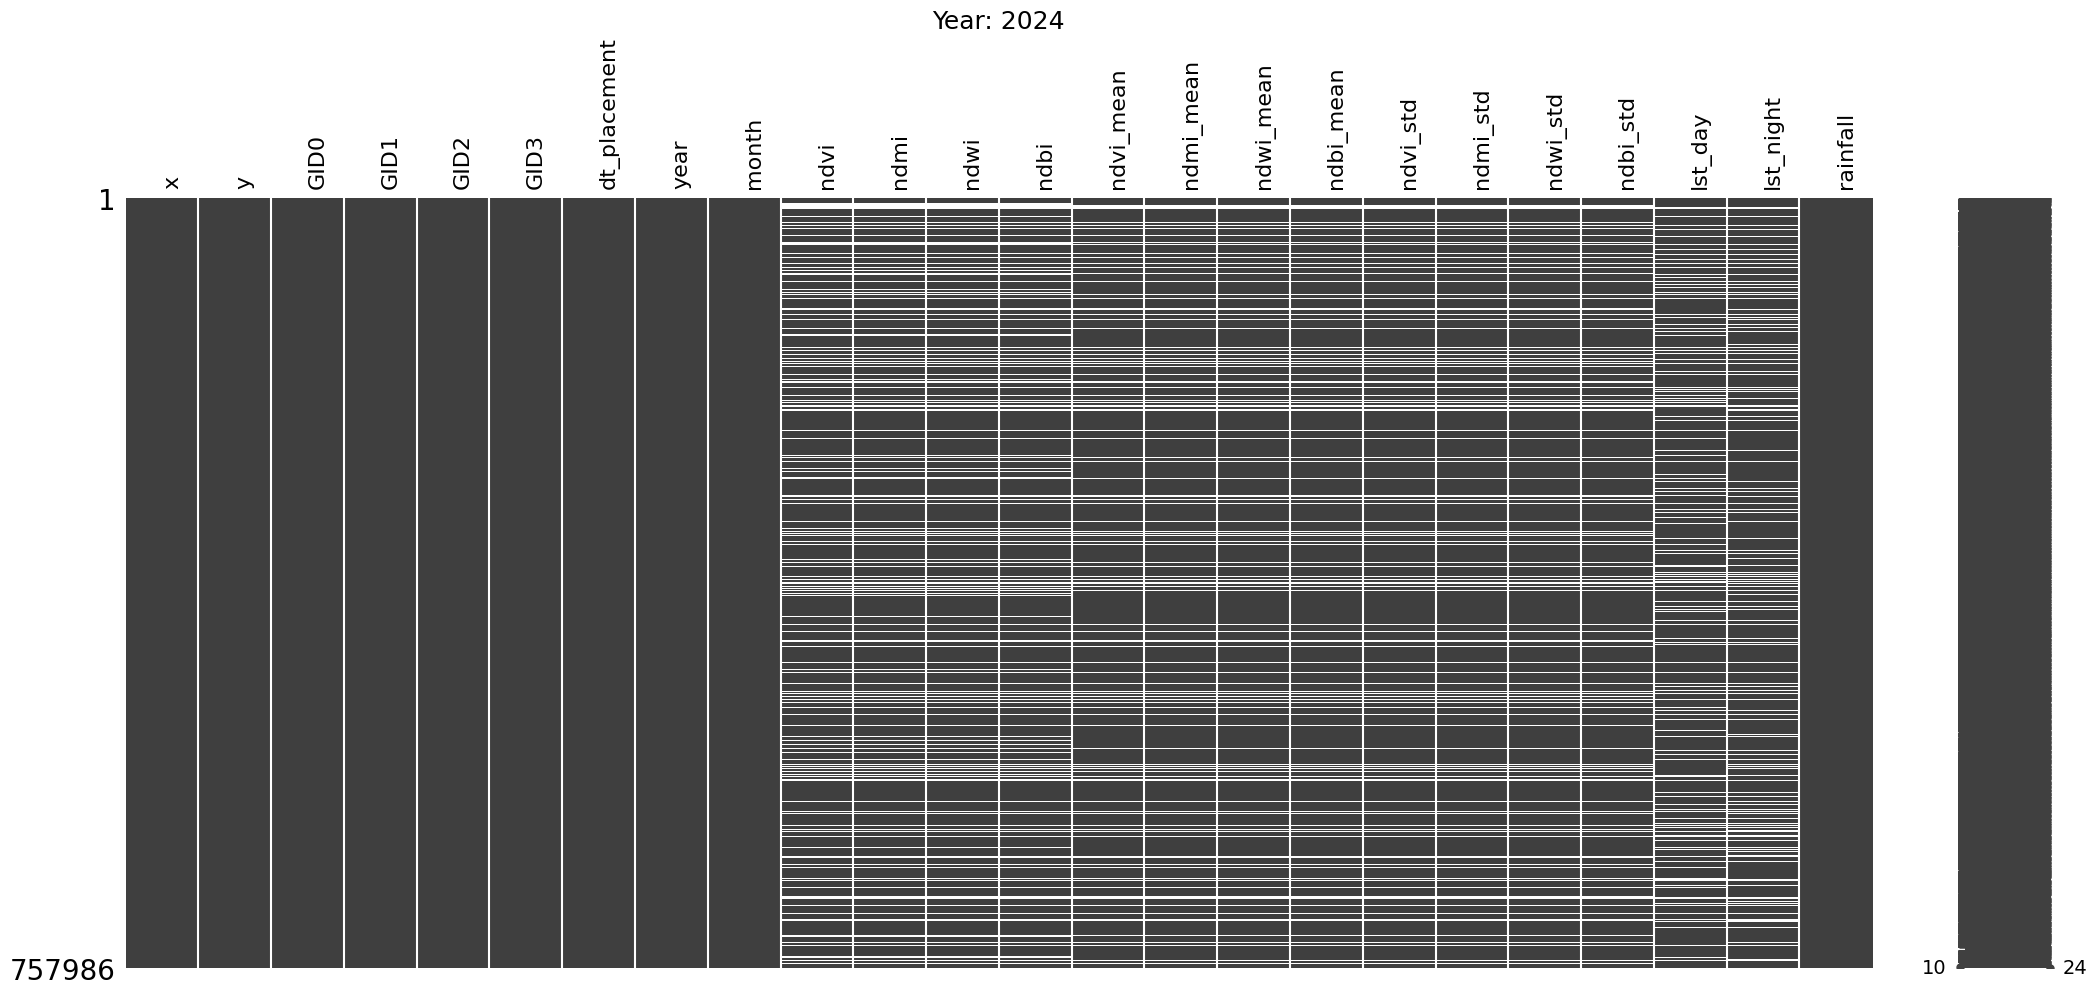

In [734]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [735]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2

In [736]:
timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [737]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-01,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15481.0,14619.0,0.00,15050.0,0.5,0.866
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-02,2024,1,0.232602,-0.082032,-0.335317,0.082032,0.223413,-0.035279,-0.274276,0.035279,0.016801,0.025556,0.033200,0.025556,15486.0,14619.0,0.43,15052.5,0.5,0.866
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-03,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15486.0,14675.0,0.14,15080.5,0.5,0.866
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-04,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15507.0,14575.0,0.10,15041.0,0.5,0.866
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-05,2024,1,0.293288,-0.097557,-0.450676,0.097557,0.293600,-0.085841,-0.445587,0.085841,0.012565,0.014310,0.011496,0.014310,15427.0,14575.0,0.06,15001.0,0.5,0.866


In [738]:
geomorphological = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Geomorphological.csv', encoding=enc)
geomorphological.columns = geomorphological.columns.str.lower()
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,14.40633,10.67157,53835.186164,422.470201,0,148.095638,374.813768,179.773696,0.0,1.265235
1,14.44281,10.67157,50119.456676,940.674765,1,144.625249,367.554596,179.818437,0.0,4.407546
2,14.44281,10.70751,48754.919418,1750.252886,3,180.563395,363.746116,179.765555,0.0,3.276963
3,14.44281,10.74344,47681.360299,697.440407,1,127.677798,358.113702,179.643406,0.0,1.867835
4,14.47929,10.70751,44973.961290,1045.737685,5,150.000751,358.118988,179.967877,0.0,1.000000


In [739]:
geomorphological['x_rounded'] = geomorphological['x'].round(4)
geomorphological['y_rounded'] = geomorphological['y'].round(4)

geomorphological.drop(columns=['x', 'y'], inplace=True)

timeline_file['x_rounded'] = timeline_file['x'].round(4)
timeline_file['y_rounded'] = timeline_file['y'].round(4)

timeline_file = pd.merge(timeline_file, geomorphological, on=['x_rounded', 'y_rounded'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-01,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15481.0,14619.0,0.00,15050.0,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-02,2024,1,0.232602,-0.082032,-0.335317,0.082032,0.223413,-0.035279,-0.274276,0.035279,0.016801,0.025556,0.033200,0.025556,15486.0,14619.0,0.43,15052.5,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-03,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15486.0,14675.0,0.14,15080.5,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-04,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15507.0,14575.0,0.10,15041.0,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-05,2024,1,0.293288,-0.097557,-0.450676,0.097557,0.293600,-0.085841,-0.445587,0.085841,0.012565,0.014310,0.011496,0.014310,15427.0,14575.0,0.06,15001.0,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908


Text(0.5, 1.0, 'Year: 2024')

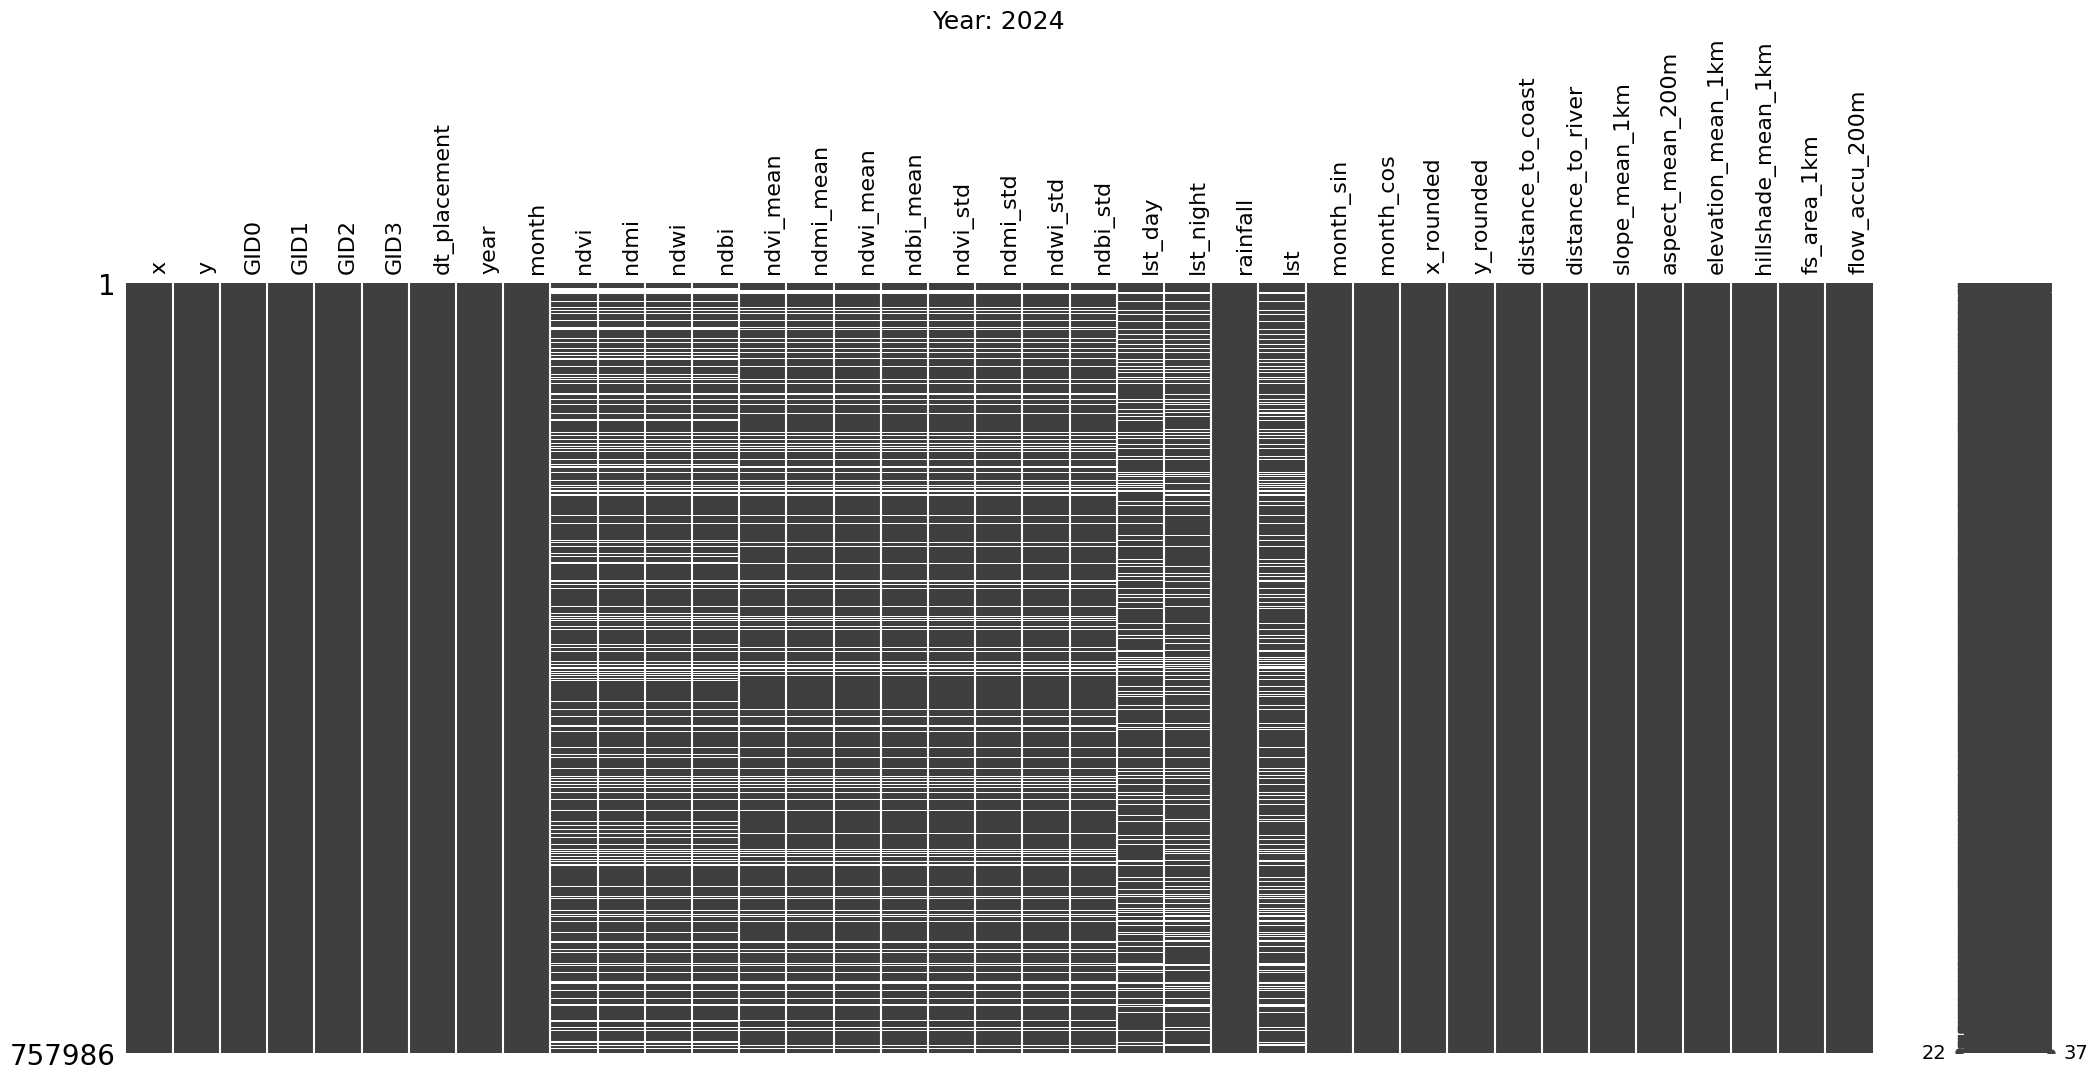

In [740]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [741]:
landcover = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Landcover_2001-2024_processed.csv')
landcover = landcover[landcover['year'] == YEAR - 1].copy()
landcover.head()

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
45562,14.40633,10.67157,2023,31,99,36,99.0,30,99,12,12,1,6,7,2,0
45563,14.44281,10.67157,2023,31,99,36,99.0,30,99,12,12,1,6,7,2,0
45564,14.44281,10.70751,2023,31,99,36,99.0,30,99,12,12,1,6,7,2,0
45565,14.44281,10.74344,2023,31,99,36,99.0,30,99,12,12,1,6,7,2,0
45566,14.47929,10.70751,2023,31,99,36,99.0,30,99,12,12,1,6,7,2,0


In [742]:
landcover['x_rounded'] = landcover['x'].round(4)
landcover['y_rounded'] = landcover['y'].round(4)
landcover.rename(columns={'year': 'year_lc'}, inplace=True)
landcover.drop(columns=['x', 'y'], inplace=True)

timeline_file['year_lc'] = timeline_file['year'] - 1

In [743]:
timeline_file = pd.merge(timeline_file, landcover, on=['x_rounded', 'y_rounded', 'year_lc'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-01,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15481.0,14619.0,0.00,15050.0,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2023,31,98,36,98.0,30,98,12,12,3,5,8,2,0
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-02,2024,1,0.232602,-0.082032,-0.335317,0.082032,0.223413,-0.035279,-0.274276,0.035279,0.016801,0.025556,0.033200,0.025556,15486.0,14619.0,0.43,15052.5,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2023,31,98,36,98.0,30,98,12,12,3,5,8,2,0
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-03,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15486.0,14675.0,0.14,15080.5,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2023,31,98,36,98.0,30,98,12,12,3,5,8,2,0
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-04,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15507.0,14575.0,0.10,15041.0,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2023,31,98,36,98.0,30,98,12,12,3,5,8,2,0
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-05,2024,1,0.293288,-0.097557,-0.450676,0.097557,0.293600,-0.085841,-0.445587,0.085841,0.012565,0.014310,0.011496,0.014310,15427.0,14575.0,0.06,15001.0,0.5,0.866,13.4348,10.1045,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2023,31,98,36,98.0,30,98,12,12,3,5,8,2,0


In [744]:
timeline_file.loc[timeline_file['lc_prop1_assessment'] < 80, 'lc_prop1'] = np.nan
timeline_file.loc[timeline_file['lc_prop2_assessment'] < 80, 'lc_prop2'] = np.nan
timeline_file.loc[timeline_file['lc_prop3_assessment'] < 80, 'lc_prop3'] = np.nan

In [745]:
timeline_file.drop(columns=['x_rounded', 'y_rounded', 'lc_prop1_assessment', 'lc_prop2_assessment', 'lc_prop3_assessment', 'lw', 'qc'], inplace=True)

Text(0.5, 1.0, 'Year: 2024')

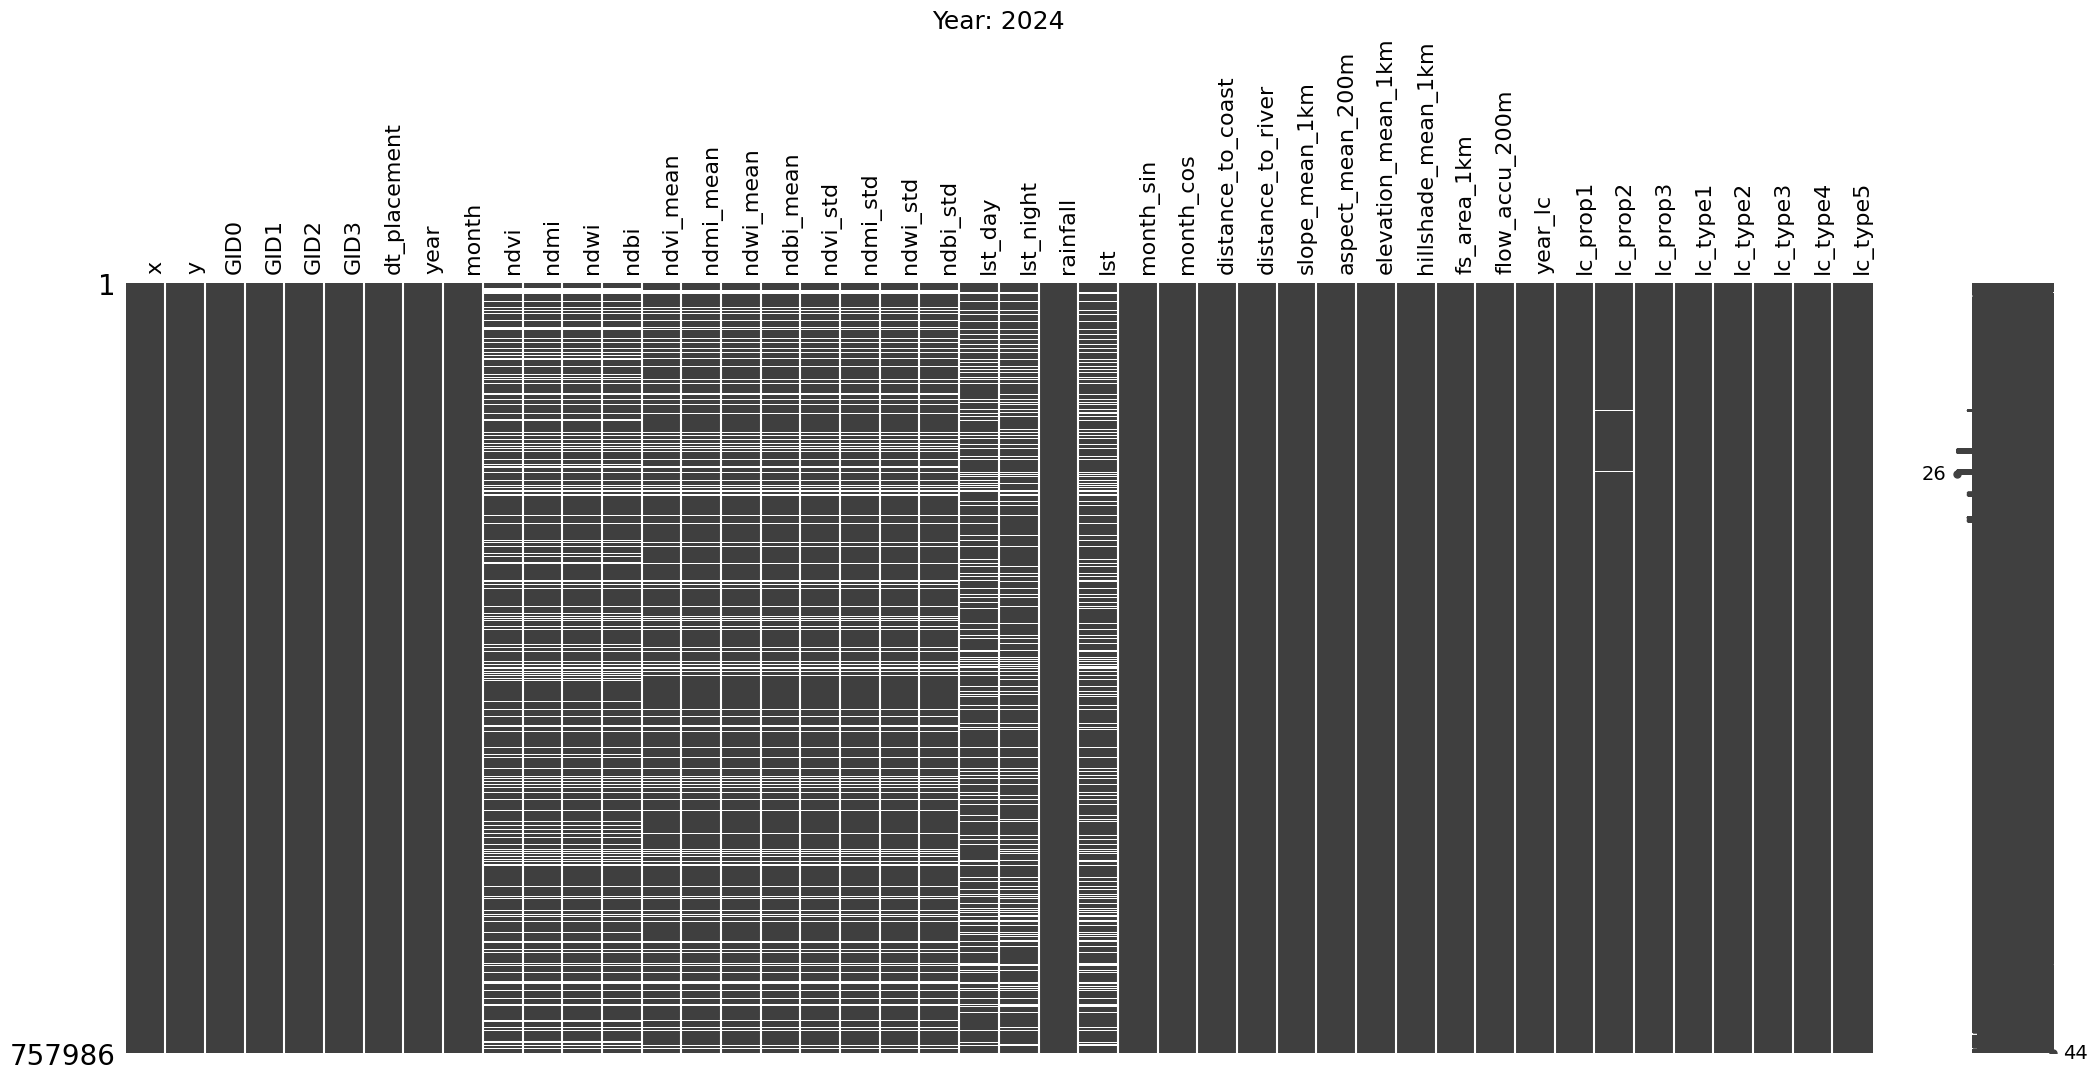

In [746]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [747]:
timeline_file

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-01,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15481.0,14619.0,0.00,15050.0,0.5,0.866,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2023,31.0,36.0,30.0,12,12,3,5,8
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-02,2024,1,0.232602,-0.082032,-0.335317,0.082032,0.223413,-0.035279,-0.274276,0.035279,0.016801,0.025556,0.033200,0.025556,15486.0,14619.0,0.43,15052.5,0.5,0.866,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2023,31.0,36.0,30.0,12,12,3,5,8
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-03,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15486.0,14675.0,0.14,15080.5,0.5,0.866,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2023,31.0,36.0,30.0,12,12,3,5,8
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-04,2024,1,0.234103,-0.148244,-0.322564,0.148244,0.228260,-0.147950,-0.328488,0.147950,0.015882,0.015968,0.013769,0.015968,15507.0,14575.0,0.10,15041.0,0.5,0.866,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2023,31.0,36.0,30.0,12,12,3,5,8
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2024-01-05,2024,1,0.293288,-0.097557,-0.450676,0.097557,0.293600,-0.085841,-0.445587,0.085841,0.012565,0.014310,0.011496,0.014310,15427.0,14575.0,0.06,15001.0,0.5,0.866,76514.407315,1617.469513,7,189.395598,871.953205,194.699531,0.0,3.207908,2023,31.0,36.0,30.0,12,12,3,5,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757981,15.35483,10.24037,extreme nord,mayo-danay,yagoua,dana,2024-12-27,2024,12,0.300792,-0.088630,-0.376792,0.088630,0.271931,-0.124079,-0.335405,0.124079,0.027836,0.026308,0.045789,0.026308,15275.0,14433.0,0.00,14854.0,-0.0,1.000,18464.933281,2894.537304,3,135.017002,327.960938,179.767605,0.0,7.699725,2023,31.0,36.0,30.0,12,12,3,5,8
757982,15.35483,10.24037,extreme nord,mayo-danay,yagoua,dana,2024-12-28,2024,12,0.297541,-0.090877,-0.375532,0.090877,0.269527,-0.126486,-0.334624,0.126486,0.025187,0.024645,0.043284,0.024645,15275.0,14607.0,0.00,14941.0,-0.0,1.000,18464.933281,2894.537304,3,135.017002,327.960938,179.767605,0.0,7.699725,2023,31.0,36.0,30.0,12,12,3,5,8
757983,15.35483,10.24037,extreme nord,mayo-danay,yagoua,dana,2024-12-29,2024,12,0.297541,-0.090877,-0.375532,0.090877,0.269527,-0.126486,-0.334624,0.126486,0.025187,0.024645,0.043284,0.024645,15169.0,14491.0,0.00,14830.0,-0.0,1.000,18464.933281,2894.537304,3,135.017002,327.960938,179.767605,0.0,7.699725,2023,31.0,36.0,30.0,12,12,3,5,8
757984,15.35483,10.24037,extreme nord,mayo-danay,yagoua,dana,2024-12-30,2024,12,0.297541,-0.090877,-0.375532,0.090877,0.269527,-0.126486,-0.334624,0.126486,0.025187,0.024645,0.043284,0.024645,15304.0,14491.0,0.00,14897.5,-0.0,1.000,18464.933281,2894.537304,3,135.017002,327.960938,179.767605,0.0,7.699725,2023,31.0,36.0,30.0,12,12,3,5,8


In [748]:
gid_unit_counts = []

for gid_unit in timeline_file.GID3.sort_values().unique().tolist():
    count = (timeline_file['GID3'] == gid_unit).sum()
    gid_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_unit_counts_df = pd.DataFrame(gid_unit_counts)

In [749]:
fig = px.bar(gid_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [750]:
group_cols = ['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3']
mode_cols = ['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5']
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']

grouped_by_gid3 = timeline_file.groupby(group_cols, as_index = False)

grouped_by_gid3_mean = grouped_by_gid3.mean()
grouped_by_gid3_std = grouped_by_gid3.std()

grouped_by_gid3_most_common = timeline_file[group_cols].drop_duplicates()

for col in mode_cols:
    mode_series = (timeline_file.groupby(group_cols)[col].value_counts().groupby(level=group_cols).idxmax().apply(lambda x: x[-1]).reset_index(name=col))
    grouped_by_gid3_most_common = grouped_by_gid3_most_common.merge(mode_series, on=group_cols, how='left')


In [751]:
grouped_by_gid3_mean.drop(columns = mode_cols, inplace=True)
grouped_by_gid3_std = grouped_by_gid3_std[group_cols + geo_cols].copy()
grouped_by_gid3_std.columns = group_cols + [f"{col}_std" for col in geo_cols]

In [752]:
grouped_by_gid3 = grouped_by_gid3_mean.merge(grouped_by_gid3_std, on=group_cols, how='left')
grouped_by_gid3 = grouped_by_gid3.merge(grouped_by_gid3_most_common, on=group_cols, how='left')

In [753]:
print(f'Shape of the grouped_by_gid3 file: {grouped_by_gid3.shape}')

Shape of the grouped_by_gid3 file: (116022, 52)


Text(0.5, 1.0, 'Year: 2024.0')

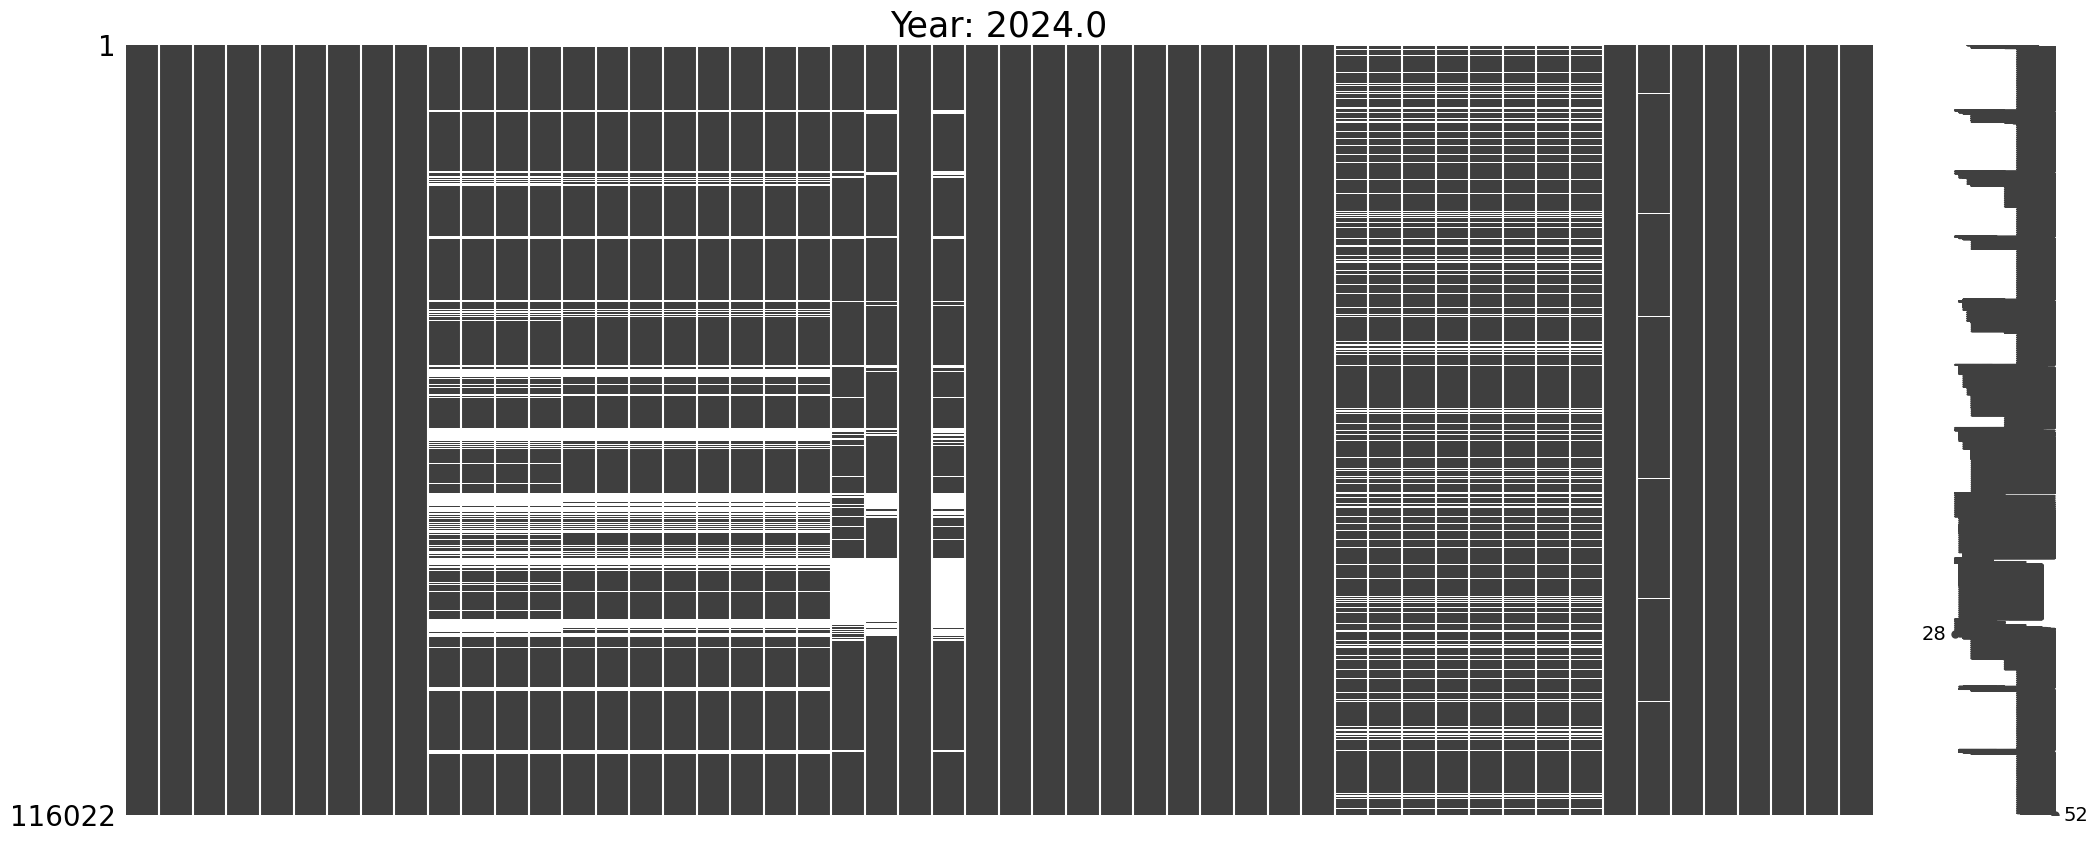

In [754]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=25)

In [755]:
gid_mean_unit_counts = []

for gid_unit in grouped_by_gid3.GID3.sort_values().unique().tolist():
    count = (grouped_by_gid3['GID3'] == gid_unit).sum()
    gid_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_mean_unit_counts_df = pd.DataFrame(gid_mean_unit_counts)

In [756]:
fig = px.bar(gid_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [757]:
grouped_by_gid3 = convert_temperature(grouped_by_gid3)

In [758]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2024-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.072667,18.487333,0.0,26.780000,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2023.0,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12,12,1,6,7
1,2024-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.550952,18.242381,0.0,26.896667,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2023.0,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12,12,1,6,7
2,2024-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.625000,19.623333,0.0,27.124167,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2023.0,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12,12,1,6,7
3,2024-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.166667,18.720000,0.0,26.443333,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2023.0,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12,12,1,6,7
4,2024-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.365000,18.726667,0.0,27.045833,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2023.0,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12,12,1,6,7


In [759]:
grouped_by_gid3['year'] = grouped_by_gid3['year'].astype(int)
grouped_by_gid3['year_lc'] = grouped_by_gid3['year_lc'].astype(int)
grouped_by_gid3['month'] = grouped_by_gid3['month'].astype(int)

In [760]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2024-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.072667,18.487333,0.0,26.780000,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2023,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12,12,1,6,7
1,2024-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.550952,18.242381,0.0,26.896667,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2023,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12,12,1,6,7
2,2024-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.625000,19.623333,0.0,27.124167,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2023,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12,12,1,6,7
3,2024-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.166667,18.720000,0.0,26.443333,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2023,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12,12,1,6,7
4,2024-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.365000,18.726667,0.0,27.045833,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2023,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12,12,1,6,7


Text(0.5, 1.0, 'Year: 2024')

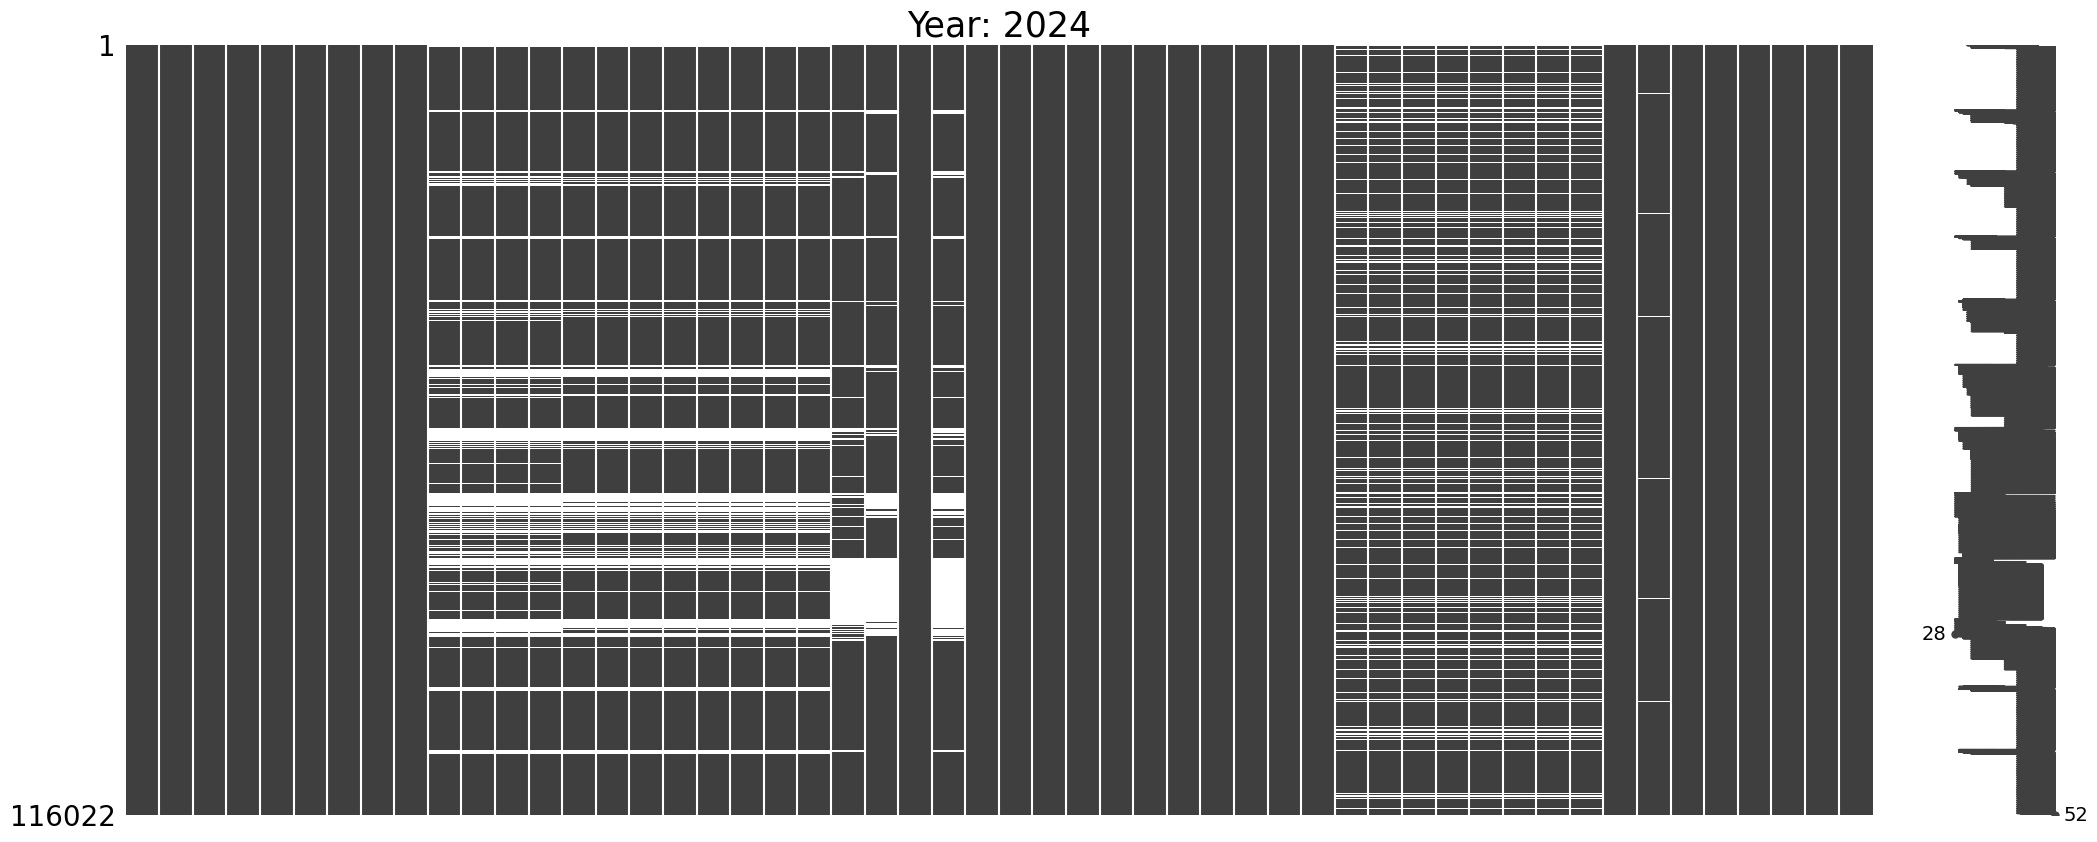

In [761]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=25)

In [762]:
# Group by the needed dimensions
grouped_mask = grouped_by_gid3.groupby(['GID2', 'GID3', 'year', 'month'])

# Compute the min and max temperature across lst_day and lst_night
monthly_lst_min = grouped_mask[['lst_day', 'lst_night']].min().min(axis=1)
monthly_lst_max = grouped_mask[['lst_day', 'lst_night']].max().max(axis=1)

# Compute total precipitation
monthly_rainfall_acc = grouped_mask['rainfall'].sum()

# Combine results into a single DataFrame
min_max_acc_weather_df = pd.DataFrame({
    'monthly_lst_min': monthly_lst_min,
    'monthly_lst_max': monthly_lst_max,
    'monthly_rainfall_acc': monthly_rainfall_acc
}).reset_index()

In [763]:
min_max_acc_weather_df

,GID2,GID3,year,month,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,bogo,balaza,2024,1,14.866000,39.702000,0.000000
1,bogo,balaza,2024,2,19.018000,44.768667,0.055333
2,bogo,balaza,2024,3,19.016667,50.279333,0.959333
3,bogo,balaza,2024,4,21.765000,49.626000,4.331333
4,bogo,balaza,2024,5,22.142000,45.894000,27.415999
...,...,...,...,...,...,...,...
3799,yagoua,yagoua,2024,8,23.010000,29.799231,670.410754
3800,yagoua,yagoua,2024,9,NaN,NaN,274.622301
3801,yagoua,yagoua,2024,10,20.805385,34.750000,163.629996
3802,yagoua,yagoua,2024,11,15.173077,35.746923,0.000000


In [764]:
dataset = pd.merge(grouped_by_gid3, min_max_acc_weather_df, on=['GID2', 'GID3', 'year', 'month'], how='left')

In [765]:
dataset.head()


,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.072667,18.487333,0.0,26.780000,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2023,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12,12,1,6,7,14.866000,39.702000,0.0
1,2024-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.550952,18.242381,0.0,26.896667,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2023,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12,12,1,6,7,15.075714,41.007143,0.0
2,2024-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.625000,19.623333,0.0,27.124167,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2023,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12,12,1,6,7,15.740000,39.240000,0.0
3,2024-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.166667,18.720000,0.0,26.443333,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2023,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12,12,1,6,7,14.863333,38.656667,0.0
4,2024-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.365000,18.726667,0.0,27.045833,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2023,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12,12,1,6,7,15.500000,40.417500,0.0


Text(0.5, 1.0, 'Year: 2024')

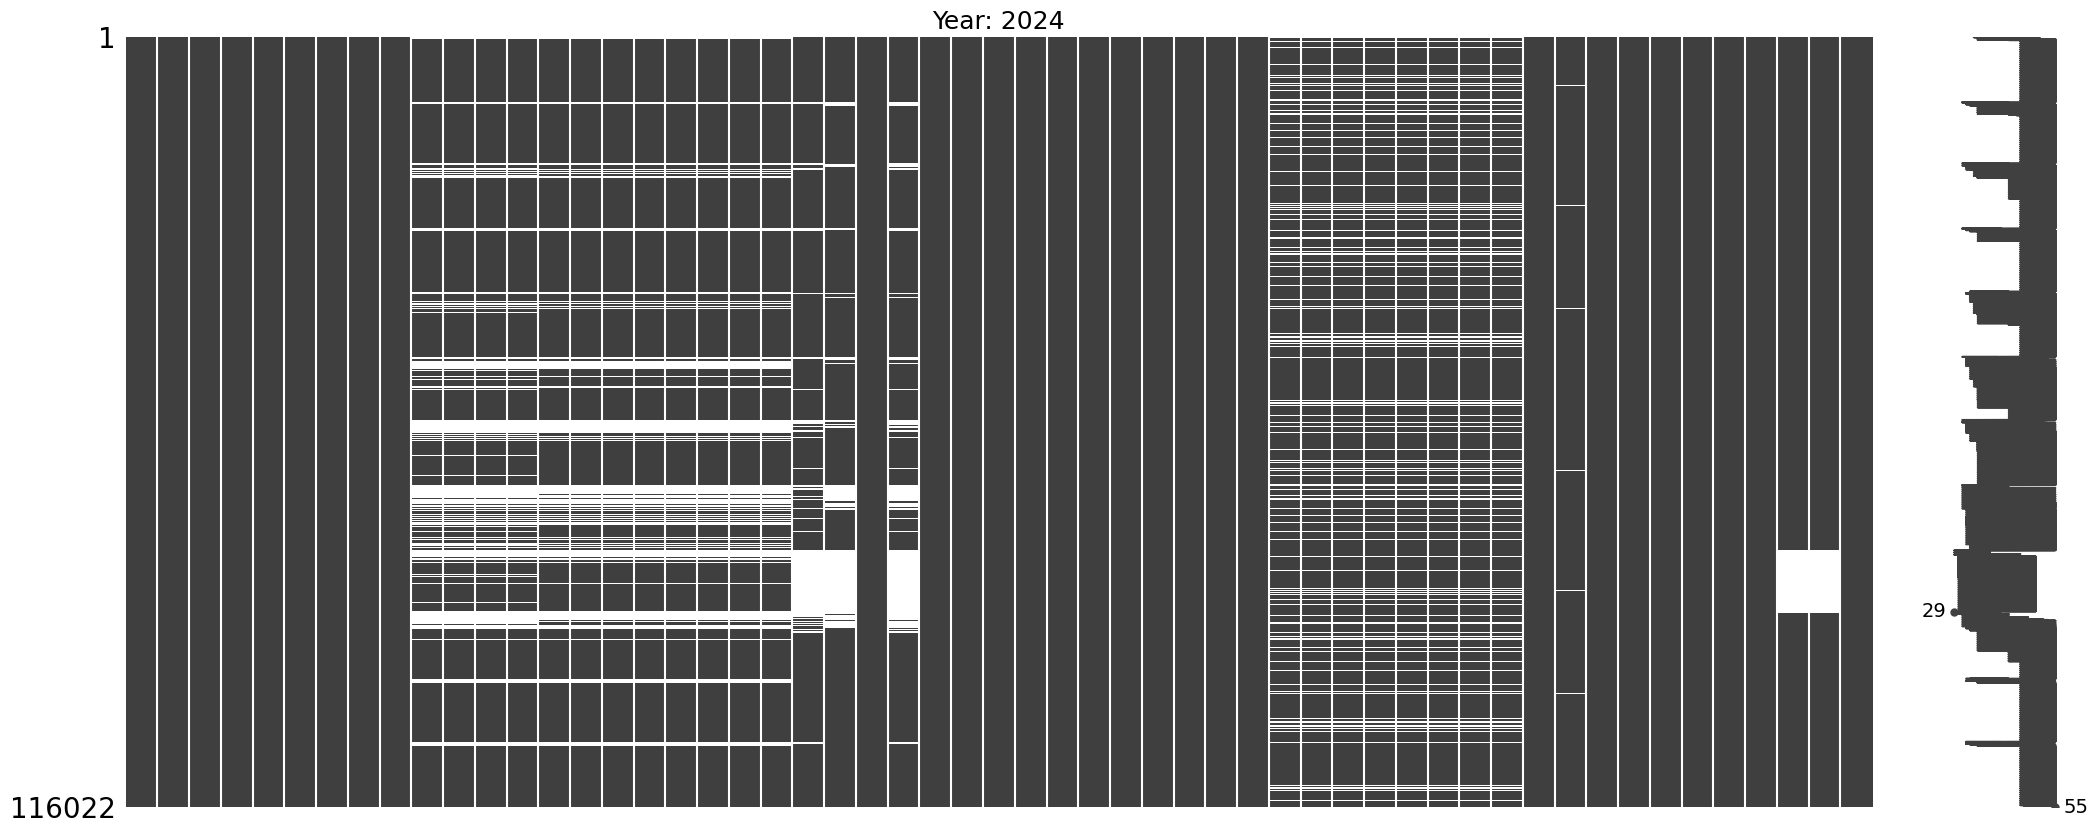

In [766]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [767]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [768]:
dataset.head()

,dt_placement_daily,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,dt_placement
0,2024-01-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.072667,18.487333,0.0,26.780000,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2023,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12,12,1,6,7,14.866000,39.702000,0.0,2024-01
1,2024-01-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.550952,18.242381,0.0,26.896667,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2023,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12,12,1,6,7,15.075714,41.007143,0.0,2024-01
2,2024-01-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.625000,19.623333,0.0,27.124167,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2023,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12,12,1,6,7,15.740000,39.240000,0.0,2024-01
3,2024-01-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.166667,18.720000,0.0,26.443333,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2023,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12,12,1,6,7,14.863333,38.656667,0.0,2024-01
4,2024-01-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.365000,18.726667,0.0,27.045833,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2023,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12,12,1,6,7,15.500000,40.417500,0.0,2024-01


In [769]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement','GID0','GID1','GID2','GID3'], as_index = False)

In [770]:
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_sum = grouped_by_month.sum()

In [771]:
grouped_by_month_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024.0,1.0,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,36.122817,18.121742,0.0,27.122280,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2023.0,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.866000,39.702000,0.0
1,2024-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024.0,1.0,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,36.875438,18.379063,0.0,27.627250,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2023.0,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.075714,41.007143,0.0
2,2024-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024.0,1.0,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,35.549516,18.652688,0.0,27.101102,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2023.0,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.740000,39.240000,0.0
3,2024-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024.0,1.0,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,34.882581,18.372581,0.0,26.627581,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2023.0,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.863333,38.656667,0.0
4,2024-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024.0,1.0,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,36.487823,18.460618,0.0,27.474220,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2023.0,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.500000,40.417500,0.0


In [772]:
print(f'Shape of the grouped_by_month_mean file: {grouped_by_month_mean.shape}')

Shape of the grouped_by_month_mean file: (3804, 55)


Text(0.5, 1.0, 'Year: 2024.0')

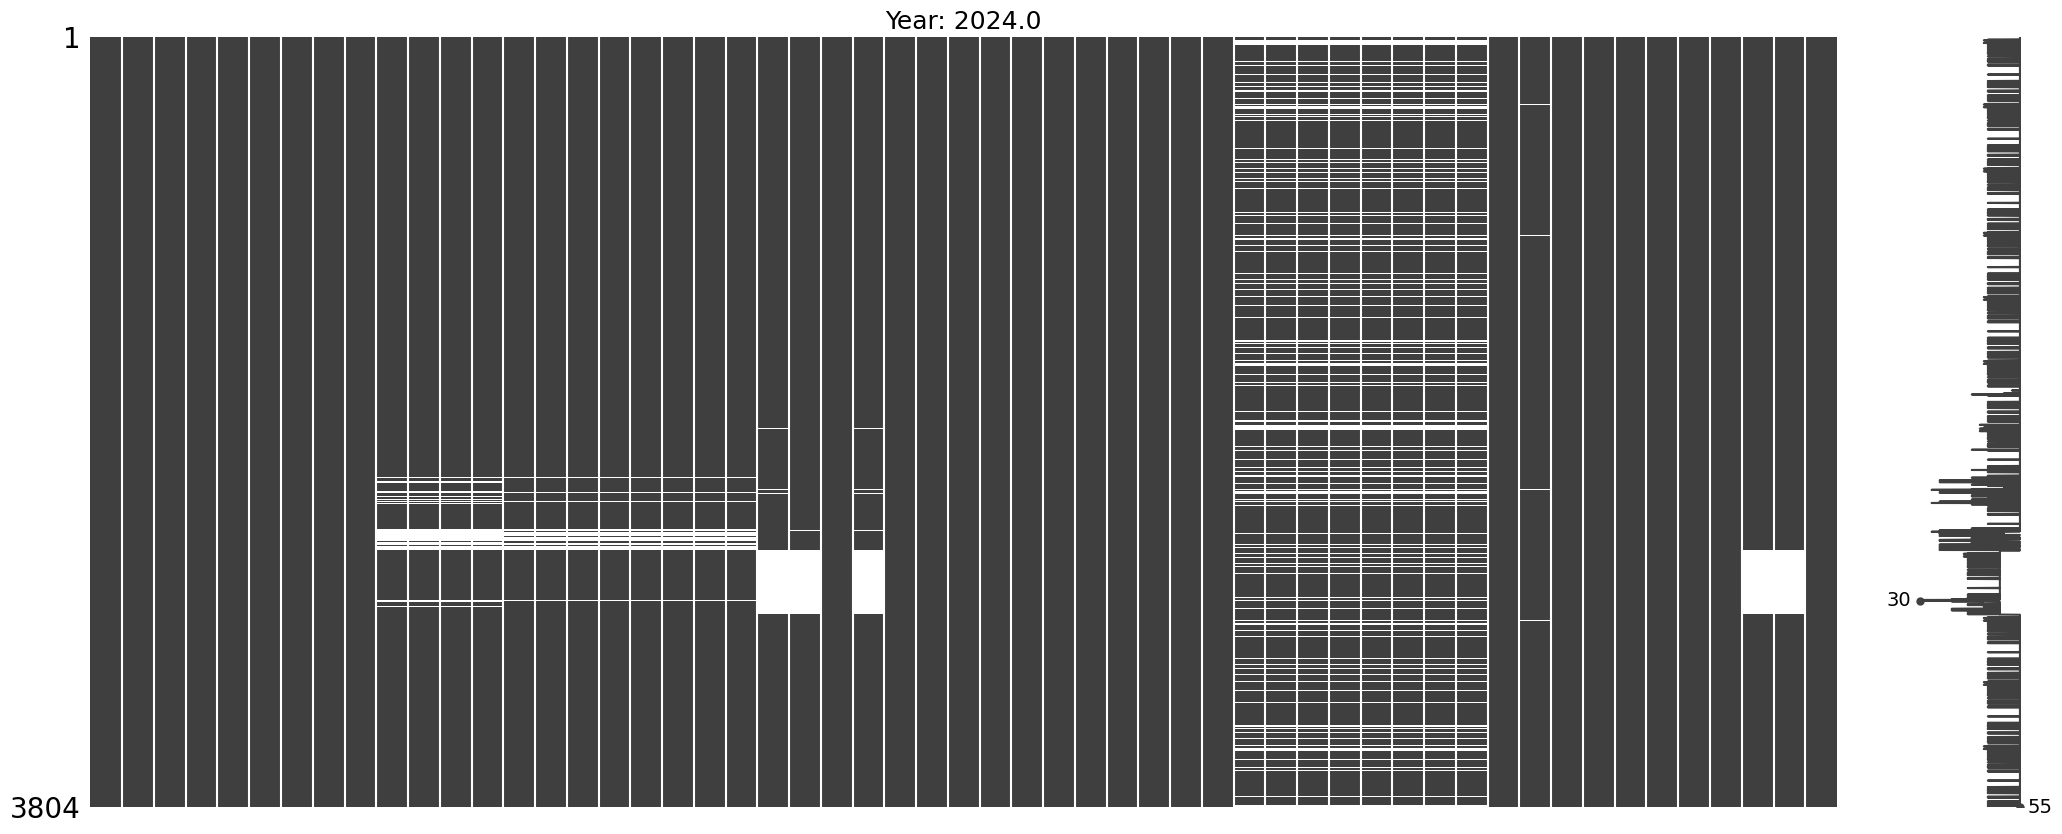

In [773]:
msno.matrix(grouped_by_month_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_month_mean.year.iloc[0]}", fontsize=18)

In [774]:
month_mean_unit_counts = []

for gid_unit in grouped_by_month_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_month_mean['GID3'] == gid_unit).sum()
    month_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

month_mean_unit_counts_df = pd.DataFrame(month_mean_unit_counts)

In [775]:
fig = px.bar(month_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [776]:
grouped_by_month_mean['year'] = grouped_by_month_mean['year'].astype(int)
grouped_by_month_mean['year_lc'] = grouped_by_month_mean['year_lc'].astype(int)
grouped_by_month_mean['month'] = grouped_by_month_mean['month'].astype(int)

In [777]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2024-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,36.122817,18.121742,0.000000,27.122280,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2023,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.866000,39.702000,0.000000
1,2024-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,36.875438,18.379063,0.000000,27.627250,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2023,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.075714,41.007143,0.000000
2,2024-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,35.549516,18.652688,0.000000,27.101102,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2023,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.740000,39.240000,0.000000
3,2024-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,34.882581,18.372581,0.000000,26.627581,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2023,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.863333,38.656667,0.000000
4,2024-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,36.487823,18.460618,0.000000,27.474220,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2023,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.500000,40.417500,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3799,2024-12,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,2024,12,0.225063,-0.138509,-0.333837,0.138509,0.231870,-0.128666,-0.337224,0.128666,0.008417,0.007810,0.008633,0.007810,29.990889,18.090000,0.046129,24.036333,0.0,1.000,108691.342579,1322.491222,4.333333,172.991986,759.462534,179.209185,0.0,62.923985,2023,2224.039515,1215.456241,3.214550,70.286429,46.802387,2.805992,0.0,93.524187,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.843333,34.863333,1.430000
3800,2024-12,extreme nord,mayo-tsanaga,roua,ndimche,13.968570,10.827287,2024,12,0.244816,-0.116837,-0.331013,0.116837,0.255033,-0.110503,-0.336593,0.110503,0.019611,0.020640,0.014236,0.020640,29.349778,18.871505,0.039462,24.106556,0.0,1.000,97846.089783,2789.944900,5.000000,159.960325,772.000791,184.722669,0.0,1.602034,2023,4050.772355,778.655345,6.928203,69.284817,62.940713,6.033922,0.0,0.98065

In [778]:
grouped_by_month_sum = grouped_by_month_sum[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'rainfall']].copy()
grouped_by_month_sum.rename(columns={"rainfall": "rainfall_acc"}, inplace=True)

dataset = pd.merge(grouped_by_month_mean, grouped_by_month_sum, on=['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [779]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc
0,2024-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,36.122817,18.121742,0.0,27.122280,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2023,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.866000,39.702000,0.0,0.0
1,2024-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,36.875438,18.379063,0.0,27.627250,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2023,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.075714,41.007143,0.0,0.0
2,2024-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,35.549516,18.652688,0.0,27.101102,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2023,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.740000,39.240000,0.0,0.0
3,2024-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,34.882581,18.372581,0.0,26.627581,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2023,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.863333,38.656667,0.0,0.0
4,2024-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,36.487823,18.460618,0.0,27.474220,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2023,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.500000,40.417500,0.0,0.0


In [780]:
dataset['location'] = list(zip(dataset['GID2'], dataset['GID3']))
grouped = dataset.groupby(['year', 'location'])
bio_var_names = [f'bio{i}' for i in range(1, 20)]

# Store results
biovars = []

# Iterate over groups
for (year, location), group in grouped:
    tmin = robjects.IntVector(group['monthly_lst_min'].tolist())
    tmax = robjects.IntVector(group['monthly_lst_max'].tolist())
    prec = robjects.IntVector(group['monthly_rainfall_acc'].tolist())

    # Call the R function
    bio_values = list(dismo.biovars(prec, tmin, tmax))

    # Construct the result dict dynamically
    result = {
        'year': year,
        'location': location,
        **dict(zip(bio_var_names, bio_values))
    }
    biovars.append(result)

# Convert to DataFrame
biovars_df = pd.DataFrame(biovars)

In [781]:
dataset = pd.merge(dataset, biovars_df,  how='left', on=['location', 'year'])

dataset.drop(columns=['location'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [782]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,36.122817,18.121742,0.000000,27.122280,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2023,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.866000,39.702000,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
1,2024-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,36.875438,18.379063,0.000000,27.627250,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2023,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.075714,41.007143,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
2,2024-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,35.549516,18.652688,0.000000,27.101102,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2023,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.740000,39.240000,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3,2024-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,34.882581,18.372581,0.000000,26.627581,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2023,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.863333,38.656667,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
4,2024-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,36.487823,18.460618,0.000000,27.474220,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2023,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.500000,40.417500,0.000000,0.000000,-2147483648,-21

Text(0.5, 1.0, 'Year: 2024')

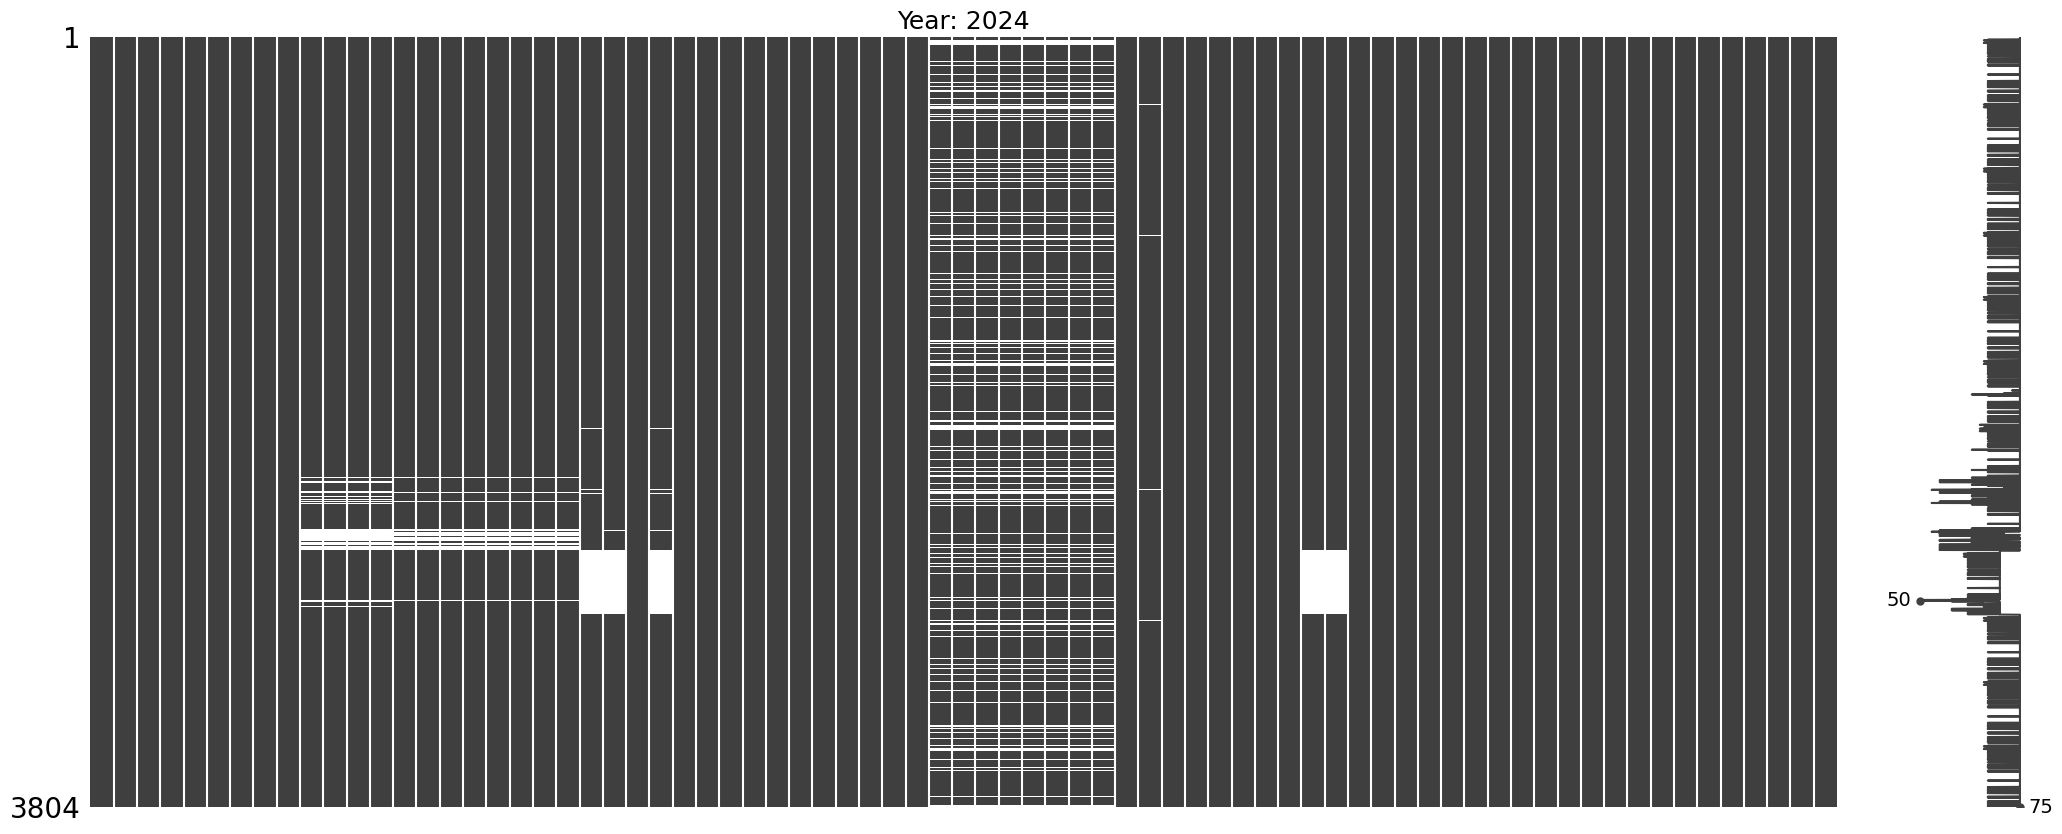

In [783]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [784]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2024,1,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,36.122817,18.121742,0.000000,27.122280,0.5,0.866,39276.651074,1226.355050,1.933333,150.781107,348.813684,179.770322,0.0,4.875292,2023,8546.384060,700.050160,1.437591,17.479150,12.988536,0.223526,0.0,11.328350,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.866000,39.702000,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
1,2024-01,extreme nord,diamare,bogo,balda,14.724237,10.914551,2024,1,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,36.875438,18.379063,0.000000,27.627250,0.5,0.866,18291.640969,963.164175,2.619048,156.138934,318.510598,179.902070,0.0,131.996538,2023,4472.682988,795.264420,1.499206,10.591687,7.151970,0.168877,0.0,326.386452,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.075714,41.007143,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
2,2024-01,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2024,1,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,35.549516,18.652688,0.000000,27.101102,0.5,0.866,31538.783837,677.096835,4.250000,161.017071,341.311941,179.700642,0.0,18.335609,2023,2223.421981,767.992161,1.500000,12.018154,3.331533,0.221276,0.0,11.729563,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.740000,39.240000,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3,2024-01,extreme nord,diamare,bogo,borai,14.606980,10.653607,2024,1,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,34.882581,18.372581,0.000000,26.627581,0.5,0.866,35412.335217,801.726350,2.500000,156.393842,340.979383,179.705531,0.0,32.700898,2023,3693.131303,560.290586,1.516575,9.358835,2.914148,0.185619,0.0,63.225569,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,14.863333,38.656667,0.000000,0.000000,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
4,2024-01,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2024,1,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,36.487823,18.460618,0.000000,27.474220,0.5,0.866,18966.677500,1323.611314,2.500000,157.368389,326.718635,179.911502,0.0,251.951188,2023,5392.490259,784.410048,1.195229,5.779442,5.713962,0.122834,0.0,705.963213,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,15.500000,40.417500,0.000000,0.000000,-2147483648,-21

In [785]:
dataset[dataset.select_dtypes(include='float').columns] = dataset.select_dtypes(include='float').round(6)

rainfall_cols = [col for col in dataset.columns if 'rainfall' in col]
dataset[rainfall_cols] = dataset[rainfall_cols].round(4)

lst_cols = [col for col in dataset.columns if 'lst' in col]
dataset[lst_cols] = dataset[lst_cols].round(2)

bio_cols = [col for col in dataset.columns if 'bio' in col]
dataset[bio_cols] = dataset[bio_cols].round(2)

geo_cols += [f"{col}_std" for col in geo_cols]
dataset[geo_cols] = dataset[geo_cols].round(2)

dataset[mode_cols] = dataset[mode_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')



In [786]:
dataset.shape

(3804, 75)

In [787]:
new_order = ['dt_placement',
             'year',
             'month',
             'year_lc',
             'month_sin',
             'month_cos',
             'GID0',
             'GID1',
             'GID2',
             'GID3',
             'x',
             'y',
             'ndvi',
             'ndmi',
             'ndwi',
             'ndbi',
             'ndvi_mean',
             'ndmi_mean',
             'ndwi_mean',
             'ndbi_mean',
             'ndvi_std',
             'ndmi_std',
             'ndwi_std',
             'ndbi_std',
             'lst',
             'lst_day',
             'lst_night',
             'monthly_lst_min',
             'monthly_lst_max',
             'rainfall',
             'rainfall_acc',
             'monthly_rainfall_acc',
             'distance_to_coast', 
             'distance_to_river', 
             'slope_mean_1km',
             'aspect_mean_200m', 
             'elevation_mean_1km', 
             'hillshade_mean_1km',
             'fs_area_1km', 
             'flow_accu_200m', 
             'distance_to_coast_std',
             'distance_to_river_std', 
             'slope_mean_1km_std', 
             'aspect_mean_200m_std',
             'elevation_mean_1km_std', 
             'hillshade_mean_1km_std', 
             'fs_area_1km_std',
             'flow_accu_200m_std', 
             'lc_prop1', 
             'lc_prop2', 
             'lc_prop3', 
             'lc_type1',
             'lc_type2', 
             'lc_type3', 
             'lc_type4', 
             'lc_type5',
             'bio1',
             'bio2',
             'bio3',
             'bio4',
             'bio5',
             'bio6',
             'bio7',
             'bio8',
             'bio9',
             'bio10',
             'bio11',
             'bio12',
             'bio13',
             'bio14',
             'bio15',
             'bio16',
             'bio17',
             'bio18',
             'bio19']

In [788]:
dataset = dataset[new_order]

In [789]:
dataset.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,2024,1,2023,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,27.12,36.12,18.12,14.87,39.70,0.0,0.0,0.0,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
1,2024-01,2024,1,2023,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,27.63,36.88,18.38,15.08,41.01,0.0,0.0,0.0,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
2,2024-01,2024,1,2023,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,27.10,35.55,18.65,15.74,39.24,0.0,0.0,0.0,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3,2024-01,2024,1,2023,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,26.63,34.88,18.37,14.86,38.66,0.0,0.0,0.0,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
4,2024-01,2024,1,2023,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,27.47,36.49,18.46,15.50,40.42,0.0,0.0,0.0,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648


In [790]:
dataset.shape

(3804, 75)

In [791]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3804 entries, 0 to 3803
Data columns (total 75 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            3804 non-null   period[M]
 1   year                    3804 non-null   int32    
 2   month                   3804 non-null   int32    
 3   year_lc                 3804 non-null   int32    
 4   month_sin               3804 non-null   float64  
 5   month_cos               3804 non-null   float64  
 6   GID0                    3804 non-null   object   
 7   GID1                    3804 non-null   object   
 8   GID2                    3804 non-null   object   
 9   GID3                    3804 non-null   object   
 10  x                       3804 non-null   float64  
 11  y                       3804 non-null   float64  
 12  ndvi                    3665 non-null   float64  
 13  ndmi                    3665 non-null   float64  
 14  ndwi    

In [792]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', index=False, encoding=enc)